# Data & Text Processing

## Import Libraries

In [14]:
import pandas as pd
import numpy as np
from deep_translator import GoogleTranslator
import re
import emoji
import string
from imblearn.over_sampling import SMOTE
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer ,AutoTokenizer
import matplotlib.pyplot as plt
import tensorflow as tf
pd.options.display.max_colwidth = None
import time

In [15]:
# Initialize Sastrawi Stemmer and Stopword Remover
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stopword_factory = StopWordRemoverFactory()
stopword_remover = stopword_factory.create_stop_word_remover()

## Using Translated Dataset

In [16]:
df = pd.read_csv('Data-Done/selected_dataset.csv')
label_count = df['Label'].value_counts()
print(label_count)

Label
0    5864
1    4835
Name: count, dtype: int64


## Text Processing

In [17]:
df

,Tweet,Label
0,@Paul_Jenkins astaga Anda akan menjadi kerja keras! 😘 Saya hanya mengikuti 20 orang sebagai aturan jadi membuat pengecualian di sini!… Https://t.co/s6vhnipxh1,0
1,@Shawnmendes sepertinya Anda berada di kamar mandi😂am saya satu -satunya yang berpikir itu?,0
2,Melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda 😓,0
3,<user> <user> <user> hampir sebagus kami pasangan di VR 😂,0
4,Yeayyy..pandai..mommy luv u begitu banyak 👨‍👩‍👦‍👦 #muhammadzharif @ alamanda pusat perbelanjaan https://t.co/st7o2iucog,0
...,...,...
10694,@user @user Kalian berdua tampak menawan! #FLOTUSrocks #MAGA 🇺🇸🙌🏾,0
10695,@user Kamu terlalu baik 😍😊🤗,0
10696,@user Berita bagus! Sinar bulan tua baru saja mengalami koma! 😂,0
10697,"@user @user Keren! Setiap antifa harus melalui Inisiasi ini""""😜""""",0


In [25]:
# Convert emojis to words
# Function to extract emojis from text
def extract_emojis(text):
    return "".join(char for char in text if char in emoji.EMOJI_DATA)

# Function to remove emojis from text
def remove_emojis(text):
    return "".join(char for char in text if char not in emoji.EMOJI_DATA)

def convert_emojis_to_words(text):
    return emoji.demojize(text)

df['Emoji'] = df['Tweet'].apply(extract_emojis)  # Get emojis
df['Text'] = df['Tweet'].apply(remove_emojis) # Get text
df['Emoji Description'] = df['Emoji'].apply(convert_emojis_to_words) # Convert emojis to description

In [26]:
df

,Tweet,Label,Emoji,Text,Emoji Description
0,@Paul_Jenkins astaga Anda akan menjadi kerja keras! 😘 Saya hanya mengikuti 20 orang sebagai aturan jadi membuat pengecualian di sini!… Https://t.co/s6vhnipxh1,0,😘,@Paul_Jenkins astaga Anda akan menjadi kerja keras! Saya hanya mengikuti 20 orang sebagai aturan jadi membuat pengecualian di sini!… Https://t.co/s6vhnipxh1,:face_blowing_a_kiss:
1,@Shawnmendes sepertinya Anda berada di kamar mandi😂am saya satu -satunya yang berpikir itu?,0,😂,@Shawnmendes sepertinya Anda berada di kamar mandiam saya satu -satunya yang berpikir itu?,:face_with_tears_of_joy:
2,Melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda 😓,0,😓,Melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda,:downcast_face_with_sweat:
3,<user> <user> <user> hampir sebagus kami pasangan di VR 😂,0,😂,<user> <user> <user> hampir sebagus kami pasangan di VR,:face_with_tears_of_joy:
4,Yeayyy..pandai..mommy luv u begitu banyak 👨‍👩‍👦‍👦 #muhammadzharif @ alamanda pusat perbelanjaan https://t.co/st7o2iucog,0,👨👩👦👦,Yeayyy..pandai..mommy luv u begitu banyak ‍‍‍ #muhammadzharif @ alamanda pusat perbelanjaan https://t.co/st7o2iucog,:man::woman::boy::boy:
...,...,...,...,...,...
10694,@user @user Kalian berdua tampak menawan! #FLOTUSrocks #MAGA 🇺🇸🙌🏾,0,🙌🏾,@user @user Kalian berdua tampak menawan! #FLOTUSrocks #MAGA 🇺🇸,:raising_hands_medium-dark_skin_tone:
10695,@user Kamu terlalu baik 😍😊🤗,0,😍😊🤗,@user Kamu terlalu baik,:smiling_face_with_heart-eyes::smiling_face_with_smiling_eyes::smiling_face_with_open_hands:
10696,@user Berita bagus! Sinar bulan tua baru saja mengalami koma! 😂,0,😂,@user Berita bagus! Sinar bulan tua baru saja mengalami koma!,:face_with_tears_of_joy:
10697,"@user @user Keren! Setiap antifa harus melalui Inisiasi ini""""😜""""",0,😜,"@user @user Keren! Setiap antifa harus melalui Inisiasi ini""""""""",:winking_face_with_tongue:


In [27]:
# Function to remove colons, double colons, underscores, and hyphens from emoji descriptions
def remove_colons(text):
    text = text.replace(":", "")
    text = text.replace("::", " ")
    text = text.replace("-", " ")
    text = text.replace("_", " ")
    return text

In [28]:
# Apply the functions to clean the "Emoji Description" column
df['Emoji Description'] = df['Emoji Description'].apply(remove_colons)

In [29]:
df

,Tweet,Label,Emoji,Text,Emoji Description
0,@Paul_Jenkins astaga Anda akan menjadi kerja keras! 😘 Saya hanya mengikuti 20 orang sebagai aturan jadi membuat pengecualian di sini!… Https://t.co/s6vhnipxh1,0,😘,@Paul_Jenkins astaga Anda akan menjadi kerja keras! Saya hanya mengikuti 20 orang sebagai aturan jadi membuat pengecualian di sini!… Https://t.co/s6vhnipxh1,face blowing a kiss
1,@Shawnmendes sepertinya Anda berada di kamar mandi😂am saya satu -satunya yang berpikir itu?,0,😂,@Shawnmendes sepertinya Anda berada di kamar mandiam saya satu -satunya yang berpikir itu?,face with tears of joy
2,Melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda 😓,0,😓,Melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda,downcast face with sweat
3,<user> <user> <user> hampir sebagus kami pasangan di VR 😂,0,😂,<user> <user> <user> hampir sebagus kami pasangan di VR,face with tears of joy
4,Yeayyy..pandai..mommy luv u begitu banyak 👨‍👩‍👦‍👦 #muhammadzharif @ alamanda pusat perbelanjaan https://t.co/st7o2iucog,0,👨👩👦👦,Yeayyy..pandai..mommy luv u begitu banyak ‍‍‍ #muhammadzharif @ alamanda pusat perbelanjaan https://t.co/st7o2iucog,manwomanboyboy
...,...,...,...,...,...
10694,@user @user Kalian berdua tampak menawan! #FLOTUSrocks #MAGA 🇺🇸🙌🏾,0,🙌🏾,@user @user Kalian berdua tampak menawan! #FLOTUSrocks #MAGA 🇺🇸,raising hands medium dark skin tone
10695,@user Kamu terlalu baik 😍😊🤗,0,😍😊🤗,@user Kamu terlalu baik,smiling face with heart eyessmiling face with smiling eyessmiling face with open hands
10696,@user Berita bagus! Sinar bulan tua baru saja mengalami koma! 😂,0,😂,@user Berita bagus! Sinar bulan tua baru saja mengalami koma!,face with tears of joy
10697,"@user @user Keren! Setiap antifa harus melalui Inisiasi ini""""😜""""",0,😜,"@user @user Keren! Setiap antifa harus melalui Inisiasi ini""""""""",winking face with tongue


In [30]:
# Function to remove URLs (http, https, www)
def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)

# Function to remove mentions (e.g., @username)
def remove_mentions(text):
    return re.sub(r"@\w+", "", text)

# Function to remove numbers
def remove_number(text):
    return re.sub(r"\d+", "", text)

# Function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

# Function to remove specific words (USER, Hashtag, URL) and placeholders
def remove_specific_terms(text):
    # Removing variations of 'user'
    text = re.sub(r"\b(user|User|USER)\b", "", text)
    # Removing variations of 'hashtag'
    text = re.sub(r"\b(hashtag|Hashtag|HASHTAG)\b", "", text)
    # Removing variations of 'url'
    text = re.sub(r"\b(url|Url|URL)\b", "", text)
    # Removing placeholders like <user>, <hashtag>, <url>
    text = re.sub(r"<user>|<hashtag>|<url>", "", text)
    # Remove words like 'rt', 'shashtag', 'gurl', etc.
    text = re.sub(r"\b(rt|shashtag|gurl|rurl|user|hashtag|url)\b", "", text)
    # Remove placeholders like <user>, <hashtag>, <url>
    text = re.sub(r"<user>|<hashtag>|<url>", "", text)
    return text

# Function to remove hashtags but keep words
def remove_hashtag(text):
    return re.sub(r"#(\w+)", r"\1", text)  # Removes # but keeps the word

In [31]:
# Function to preprocess text in a DataFrame
def preprocessing(df):
    # Ensure text format
    df['Text'] = df['Text'].astype(str)

    # Apply preprocessing steps in the correct order
    df['Text'] = df['Text'].str.lower()  # Convert to lowercase
    df['Text'] = df['Text'].apply(remove_urls)  # Remove URLs
    df['Text'] = df['Text'].apply(remove_mentions)  # Remove @username mentions
    df['Text'] = df['Text'].apply(remove_number)  # Remove numbers
    df['Text'] = df['Text'].apply(remove_punctuation)  # Remove punctuation
    df['Text'] = df['Text'].apply(remove_specific_terms)  # Remove USER, Hashtag, URL, etc.
    df['Text'] = df['Text'].apply(remove_hashtag)  # Remove # but keep words

    return df['Text']

In [32]:
df['Text'] = preprocessing(df)
df

,Tweet,Label,Emoji,Text,Emoji Description
0,@Paul_Jenkins astaga Anda akan menjadi kerja keras! 😘 Saya hanya mengikuti 20 orang sebagai aturan jadi membuat pengecualian di sini!… Https://t.co/s6vhnipxh1,0,😘,astaga anda akan menjadi kerja keras saya hanya mengikuti orang sebagai aturan jadi membuat pengecualian di sini…,face blowing a kiss
1,@Shawnmendes sepertinya Anda berada di kamar mandi😂am saya satu -satunya yang berpikir itu?,0,😂,sepertinya anda berada di kamar mandiam saya satu satunya yang berpikir itu,face with tears of joy
2,Melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda 😓,0,😓,melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda,downcast face with sweat
3,<user> <user> <user> hampir sebagus kami pasangan di VR 😂,0,😂,hampir sebagus kami pasangan di vr,face with tears of joy
4,Yeayyy..pandai..mommy luv u begitu banyak 👨‍👩‍👦‍👦 #muhammadzharif @ alamanda pusat perbelanjaan https://t.co/st7o2iucog,0,👨👩👦👦,yeayyypandaimommy luv u begitu banyak ‍‍‍ muhammadzharif alamanda pusat perbelanjaan,manwomanboyboy
...,...,...,...,...,...
10694,@user @user Kalian berdua tampak menawan! #FLOTUSrocks #MAGA 🇺🇸🙌🏾,0,🙌🏾,kalian berdua tampak menawan flotusrocks maga 🇺🇸,raising hands medium dark skin tone
10695,@user Kamu terlalu baik 😍😊🤗,0,😍😊🤗,kamu terlalu baik,smiling face with heart eyessmiling face with smiling eyessmiling face with open hands
10696,@user Berita bagus! Sinar bulan tua baru saja mengalami koma! 😂,0,😂,berita bagus sinar bulan tua baru saja mengalami koma,face with tears of joy
10697,"@user @user Keren! Setiap antifa harus melalui Inisiasi ini""""😜""""",0,😜,keren setiap antifa harus melalui inisiasi ini,winking face with tongue


In [33]:
# Translate Column Tweet
def translate_text(text, source='en', target='id', retries=3):
    """
    Fungsi untuk menerjemahkan teks dengan mekanisme retry jika terjadi error.
    """
    for attempt in range(retries):
        try:
            translated_text = GoogleTranslator(source=source, target=target).translate(text)
            return translated_text
        except Exception as e:
            print(f"Error occurred: {e} - Retrying ({attempt+1}/{retries})")
            time.sleep(5)  # Wait for 5 seconds before retrying
    return None  # If fail return None

In [34]:
start_time = time.time()

# Translating 'Tweet'
df['Emoji Description Indonesia'] = df['Emoji Description'].apply(lambda x: translate_text(x, source='en', target='id'))

# Stop TIMER 
end_time = time.time()
elapsed_time = end_time - start_time

# Print execution time
print(f"\n✅ Translation completed in {elapsed_time:.2f} seconds ⏳")


✅ Translation completed in 3709.32 seconds ⏳


In [35]:
df.to_csv('Data-Done/emojidesc_translated_dataset.csv', index=False)

In [36]:
df

,Tweet,Label,Emoji,Text,Emoji Description,Emoji Description Indonesia
0,@Paul_Jenkins astaga Anda akan menjadi kerja keras! 😘 Saya hanya mengikuti 20 orang sebagai aturan jadi membuat pengecualian di sini!… Https://t.co/s6vhnipxh1,0,😘,astaga anda akan menjadi kerja keras saya hanya mengikuti orang sebagai aturan jadi membuat pengecualian di sini…,face blowing a kiss,wajah meniup ciuman
1,@Shawnmendes sepertinya Anda berada di kamar mandi😂am saya satu -satunya yang berpikir itu?,0,😂,sepertinya anda berada di kamar mandiam saya satu satunya yang berpikir itu,face with tears of joy,wajah dengan air mata sukacita
2,Melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda 😓,0,😓,melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda,downcast face with sweat,Wajah Downcast dengan Keringat
3,<user> <user> <user> hampir sebagus kami pasangan di VR 😂,0,😂,hampir sebagus kami pasangan di vr,face with tears of joy,wajah dengan air mata sukacita
4,Yeayyy..pandai..mommy luv u begitu banyak 👨‍👩‍👦‍👦 #muhammadzharif @ alamanda pusat perbelanjaan https://t.co/st7o2iucog,0,👨👩👦👦,yeayyypandaimommy luv u begitu banyak ‍‍‍ muhammadzharif alamanda pusat perbelanjaan,manwomanboyboy,manwomanboy
...,...,...,...,...,...,...
10694,@user @user Kalian berdua tampak menawan! #FLOTUSrocks #MAGA 🇺🇸🙌🏾,0,🙌🏾,kalian berdua tampak menawan flotusrocks maga 🇺🇸,raising hands medium dark skin tone,Mengangkat tangan warna kulit gelap sedang
10695,@user Kamu terlalu baik 😍😊🤗,0,😍😊🤗,kamu terlalu baik,smiling face with heart eyessmiling face with smiling eyessmiling face with open hands,Wajah tersenyum dengan hati yang melingkari wajah dengan wajah tersenyum yang tersenyum dengan tangan terbuka
10696,@user Berita bagus! Sinar bulan tua baru saja mengalami koma! 😂,0,😂,berita bagus sinar bulan tua baru saja mengalami koma,face with tears of joy,wajah dengan air mata sukacita
10697,"@user @user Keren! Setiap antifa harus melalui Inisiasi ini""""😜""""",0,😜,keren setiap antifa harus melalui inisiasi ini,winking face with tongue,Winking Face with Lidah


In [37]:
# Create a new column by merging 'Text' and 'Emoji Description Indonesia'
df['Tweet_EmojiDesc'] = df['Text'] + " " + df['Emoji Description Indonesia']
df

,Tweet,Label,Emoji,Text,Emoji Description,Emoji Description Indonesia,Tweet_EmojiDesc
0,@Paul_Jenkins astaga Anda akan menjadi kerja keras! 😘 Saya hanya mengikuti 20 orang sebagai aturan jadi membuat pengecualian di sini!… Https://t.co/s6vhnipxh1,0,😘,astaga anda akan menjadi kerja keras saya hanya mengikuti orang sebagai aturan jadi membuat pengecualian di sini…,face blowing a kiss,wajah meniup ciuman,astaga anda akan menjadi kerja keras saya hanya mengikuti orang sebagai aturan jadi membuat pengecualian di sini… wajah meniup ciuman
1,@Shawnmendes sepertinya Anda berada di kamar mandi😂am saya satu -satunya yang berpikir itu?,0,😂,sepertinya anda berada di kamar mandiam saya satu satunya yang berpikir itu,face with tears of joy,wajah dengan air mata sukacita,sepertinya anda berada di kamar mandiam saya satu satunya yang berpikir itu wajah dengan air mata sukacita
2,Melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda 😓,0,😓,melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda,downcast face with sweat,Wajah Downcast dengan Keringat,melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda Wajah Downcast dengan Keringat
3,<user> <user> <user> hampir sebagus kami pasangan di VR 😂,0,😂,hampir sebagus kami pasangan di vr,face with tears of joy,wajah dengan air mata sukacita,hampir sebagus kami pasangan di vr wajah dengan air mata sukacita
4,Yeayyy..pandai..mommy luv u begitu banyak 👨‍👩‍👦‍👦 #muhammadzharif @ alamanda pusat perbelanjaan https://t.co/st7o2iucog,0,👨👩👦👦,yeayyypandaimommy luv u begitu banyak ‍‍‍ muhammadzharif alamanda pusat perbelanjaan,manwomanboyboy,manwomanboy,yeayyypandaimommy luv u begitu banyak ‍‍‍ muhammadzharif alamanda pusat perbelanjaan manwomanboy
...,...,...,...,...,...,...,...
10694,@user @user Kalian berdua tampak menawan! #FLOTUSrocks #MAGA 🇺🇸🙌🏾,0,🙌🏾,kalian berdua tampak menawan flotusrocks maga 🇺🇸,raising hands medium dark skin tone,Mengangkat tangan warna kulit gelap sedang,kalian berdua tampak menawan flotusrocks maga 🇺🇸 Mengangkat tangan warna kulit gelap sedang
10695,@user Kamu terlalu baik 😍😊🤗,0,😍😊🤗,kamu terlalu baik,smiling face with heart eyessmiling face with smiling eyessmiling face with open hands,Wajah tersenyum dengan hati yang melingkari wajah dengan wajah tersenyum yang tersenyum dengan tangan terbuka,kamu terlalu baik Wajah tersenyum dengan hati yang melingkari wajah dengan wajah tersenyum yang tersenyum dengan tangan terbuka
10696,@user Berita bagus! Sinar bulan tua baru saja mengalami koma! 😂,0,😂,berita bagus sinar bulan tua baru saja mengalami koma,face with tears of joy,wajah dengan air mata sukacita,berita bagus sinar bulan tua baru saja mengalami koma wajah dengan air mata sukacita
10697,"@user @user Keren! Setiap antifa harus melalui Inisiasi ini""""😜""""",0,😜,keren setiap antifa harus melalui inisiasi ini,winking face with tongue,Winking Face with Lidah,keren setiap antifa harus melalui inisiasi ini Winking Face with Lidah


In [38]:
# Function to remove stopwords using Sastrawi
def remove_stopwords(text):
    return stopword_remover.remove(text)

# Function to apply stemming using Sastrawi
def stemming(text):
    return stemmer.stem(text)

In [39]:
# Function to preprocess text in a DataFrame
def preprocessing(df):
    df['Tweet_EmojiDesc'] = df['Tweet_EmojiDesc'].apply(remove_stopwords)  # Remove stopwords using Sastrawi
    df['Tweet_EmojiDesc'] = df['Tweet_EmojiDesc'].apply(stemming) # Apply stemming using Sastrawi

    return df['Tweet_EmojiDesc']

In [40]:
df['Tweet_EmojiDesc'] = preprocessing(df)
df

,Tweet,Label,Emoji,Text,Emoji Description,Emoji Description Indonesia,Tweet_EmojiDesc
0,@Paul_Jenkins astaga Anda akan menjadi kerja keras! 😘 Saya hanya mengikuti 20 orang sebagai aturan jadi membuat pengecualian di sini!… Https://t.co/s6vhnipxh1,0,😘,astaga anda akan menjadi kerja keras saya hanya mengikuti orang sebagai aturan jadi membuat pengecualian di sini…,face blowing a kiss,wajah meniup ciuman,astaga akan jadi kerja keras hanya ikut orang atur jadi buat kecuali sini wajah tiup cium
1,@Shawnmendes sepertinya Anda berada di kamar mandi😂am saya satu -satunya yang berpikir itu?,0,😂,sepertinya anda berada di kamar mandiam saya satu satunya yang berpikir itu,face with tears of joy,wajah dengan air mata sukacita,seperti ada kamar mandiam satu satu pikir wajah air mata sukacita
2,Melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda 😓,0,😓,melihat ibumu adalah rasa sakit adalah jenis rasa sakit yang berbeda,downcast face with sweat,Wajah Downcast dengan Keringat,lihat ibu rasa sakit jenis rasa sakit beda wajah downcast keringat
3,<user> <user> <user> hampir sebagus kami pasangan di VR 😂,0,😂,hampir sebagus kami pasangan di vr,face with tears of joy,wajah dengan air mata sukacita,hampir bagus pasang vr wajah air mata sukacita
4,Yeayyy..pandai..mommy luv u begitu banyak 👨‍👩‍👦‍👦 #muhammadzharif @ alamanda pusat perbelanjaan https://t.co/st7o2iucog,0,👨👩👦👦,yeayyypandaimommy luv u begitu banyak ‍‍‍ muhammadzharif alamanda pusat perbelanjaan,manwomanboyboy,manwomanboy,yeayyypandaimommy luv u banyak muhammadzharif alamanda pusat belanja manwomanboy
...,...,...,...,...,...,...,...
10694,@user @user Kalian berdua tampak menawan! #FLOTUSrocks #MAGA 🇺🇸🙌🏾,0,🙌🏾,kalian berdua tampak menawan flotusrocks maga 🇺🇸,raising hands medium dark skin tone,Mengangkat tangan warna kulit gelap sedang,kalian dua tampak tawan flotusrocks maga angkat tangan warna kulit gelap sedang
10695,@user Kamu terlalu baik 😍😊🤗,0,😍😊🤗,kamu terlalu baik,smiling face with heart eyessmiling face with smiling eyessmiling face with open hands,Wajah tersenyum dengan hati yang melingkari wajah dengan wajah tersenyum yang tersenyum dengan tangan terbuka,kamu terlalu baik wajah senyum hati lingkar wajah wajah senyum senyum tangan buka
10696,@user Berita bagus! Sinar bulan tua baru saja mengalami koma! 😂,0,😂,berita bagus sinar bulan tua baru saja mengalami koma,face with tears of joy,wajah dengan air mata sukacita,berita bagus sinar bulan tua baru alami koma wajah air mata sukacita
10697,"@user @user Keren! Setiap antifa harus melalui Inisiasi ini""""😜""""",0,😜,keren setiap antifa harus melalui inisiasi ini,winking face with tongue,Winking Face with Lidah,keren antifa lalu inisiasi winking face with lidah


In [41]:
df.to_csv('Data-Done/emojidesc_stemmed_dataset.csv', index=False)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10699 entries, 0 to 10698
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Tweet                        10699 non-null  object
 1   Label                        10699 non-null  int64 
 2   Emoji                        10699 non-null  object
 3   Text                         10699 non-null  object
 4   Emoji Description            10699 non-null  object
 5   Emoji Description Indonesia  10699 non-null  object
 6   Tweet_EmojiDesc              10699 non-null  object
dtypes: int64(1), object(6)
memory usage: 585.2+ KB


In [43]:
# check percentages of each label
label_percentages = (label_count / label_count.sum()) * 100
label_percentages

Label
0    54.808861
1    45.191139
Name: count, dtype: float64

## Data Oversampling

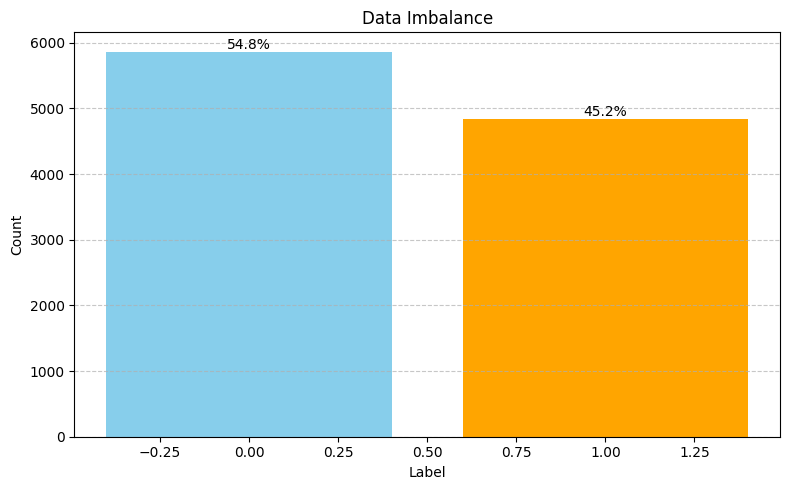

In [44]:
plt.figure(figsize=(8, 5))
bars = plt.bar(label_count.index, label_count, color=['skyblue', 'orange'])

# add percentages on top of bars
for bar, percentage in zip(bars, label_percentages):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{percentage:.1f}%',
             ha='center', va='bottom', fontsize=10)

# add chart title 
plt.title('Data Imbalance')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [45]:
# The data is imbalanced, so we will use SMOTE to balance the data
# but first, we need to tokenize the text data and get the integer representation of the tokens

# Tokenization
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-lite-base-p1")

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'AlbertTokenizer'. 
The class this function is called from is 'BertTokenizer'.


In [46]:
def tokenize_text(text, max_length=500):
    if not isinstance(text, list):
      raise ValueError("Input must be a list of strings.")
    encoded = tokenizer(text, padding=True, truncation=True, max_length=max_length, return_tensors='tf')
    token_ids = encoded['input_ids']
    attention_mask = encoded['attention_mask']

    return token_ids, attention_mask

In [47]:
token_ids, attention_mask = tokenize_text(df['Tweet'].tolist())

In [48]:
# Split the dataset to X and y to apply SMOTE
X = token_ids.numpy()
y = df['Label'].values

In [49]:
X

array([[    2, 29956,  9892, ...,     0,     0,     0],
       [    2, 29956, 27413, ...,     0,     0,     0],
       [    2,   722, 19734, ...,     0,     0,     0],
       ...,
       [    2, 29956,  6273, ...,     0,     0,     0],
       [    2, 29956,  6273, ...,     0,     0,     0],
       [    2, 29956,  6273, ...,     0,     0,     0]])

In [50]:
# Count majority and minority classes
majority_class_count = df['Label'].value_counts().max()

# Apply SMOTE to balance the data
def apply_smote(X, y, auto, k=5):
    smote = SMOTE(sampling_strategy=auto, k_neighbors=k, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    return X_resampled, y_resampled

X_resampled, y_resampled = apply_smote(X, y, auto='auto', k=5)

In [53]:
# Check the shape of the resampled data
label_counts = pd.Series(y_resampled).value_counts()
print(label_counts)

0    5864
1    5864
Name: count, dtype: int64


In [54]:
# check percentages of each label
label_percentages = (label_counts / label_counts.sum()) * 100
label_percentages

0    50.0
1    50.0
Name: count, dtype: float64

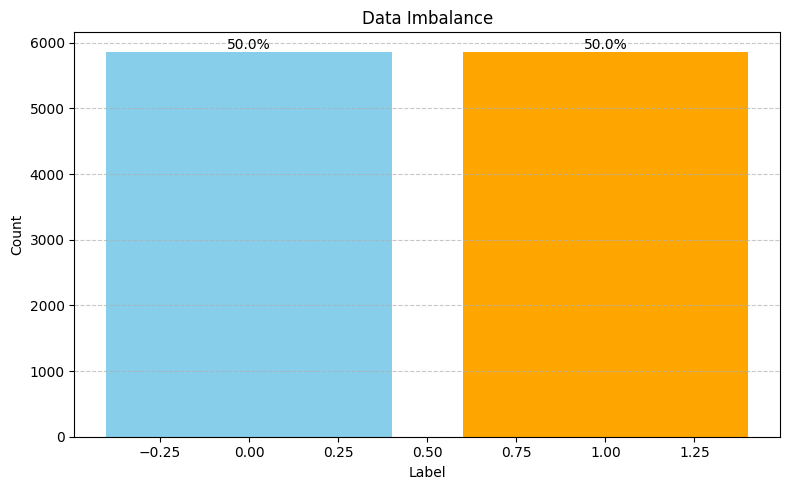

In [55]:
plt.figure(figsize=(8, 5))
bars = plt.bar(label_counts.index, label_counts, color=['skyblue', 'orange'])

# Menambahkan persentase di atas setiap batang
for bar, percentage in zip(bars, label_percentages):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{percentage:.1f}%',
             ha='center', va='bottom', fontsize=10)

# Menambahkan judul dan label sumbu
plt.title('Data Imbalance')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Split Data

In [56]:
# Split the data into training, testing, and validation sets
# Training 80% | Testing 10% | Validation 10%
X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Training data shape:", X_train.shape, y_train.shape)
print("Testing data shape:", X_test.shape, y_test.shape)
print("Validation data shape:", X_val.shape, y_val.shape)

Training data shape: (9382, 150) (9382,)
Testing data shape: (1173, 150) (1173,)
Validation data shape: (1173, 150) (1173,)


In [57]:
# prompt: Simpan dataset train, val, dan test ke path Data-TTV/nama_file.csv
pd.DataFrame(X_train).to_csv('Data-TTV-Emojidesc/X_train.csv', index=False)
pd.DataFrame(y_train).to_csv('Data-TTV-Emojidesc/y_train.csv', index=False)
pd.DataFrame(X_val).to_csv('Data-TTV-Emojidesc/X_val.csv', index=False)
pd.DataFrame(y_val).to_csv('Data-TTV-Emojidesc/y_val.csv', index=False)
pd.DataFrame(X_test).to_csv('Data-TTV-Emojidesc/X_test.csv', index=False)
pd.DataFrame(y_test).to_csv('Data-TTV-Emojidesc/y_test.csv', index=False)

In [ ]:
# Continue to the next step: Model Training